# Age Distribution of Infants
This notebook plots the distribution of acquisition ages (in years) for all EEG sessions in the dataset.

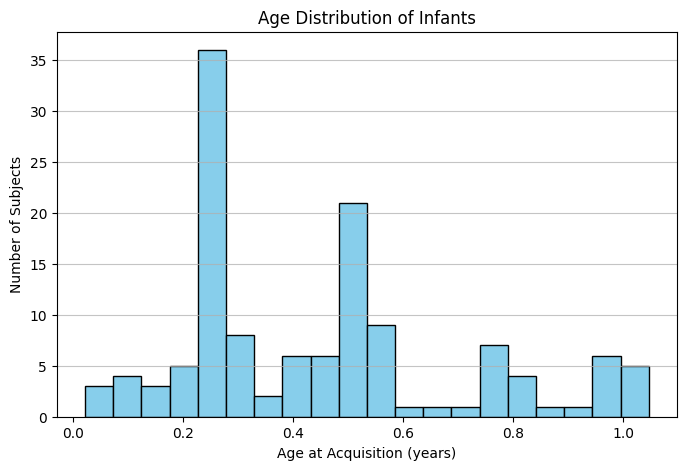

In [2]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# Path to the Infants_data directory
base_dir = 'Infants_data'

# Find all scans.tsv files recursively
scan_files = glob.glob(os.path.join(base_dir, 'sub-NORB*/ses-*', 'sub-NORB*_ses-*_scans.tsv'))

ages = []
for scan_file in scan_files:
    try:
        df = pd.read_csv(scan_file, sep='\t')
        if 'age_acq_time' in df.columns:
            ages.extend(df['age_acq_time'].dropna().tolist())
    except Exception as e:
        print(f'Error reading {scan_file}: {e}')

plt.figure(figsize=(8, 5))
plt.hist(ages, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Age at Acquisition (years)')
plt.ylabel('Number of Subjects')
plt.title('Age Distribution of Infants')
plt.grid(axis='y', alpha=0.75)
plt.show()

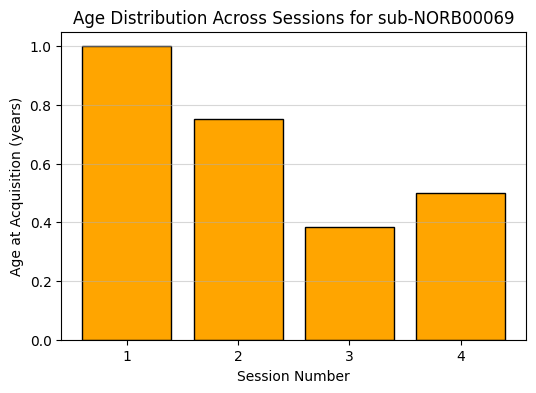

In [ ]:
# Plot age distribution for a single subject across sessions
# Change subject_id as needed (e.g., 'sub-NORB00001')
subject_id = 'sub-NORB00064'
subject_dir = os.path.join(base_dir, subject_id)
session_dirs = glob.glob(os.path.join(subject_dir, 'ses-*'))
subject_ages = []
for session_dir in session_dirs:
    scan_files = glob.glob(os.path.join(session_dir, f'{subject_id}_ses-*_scans.tsv'))
    for scan_file in scan_files:
        try:
            df = pd.read_csv(scan_file, sep='\t')
            if 'age_acq_time' in df.columns:
                subject_ages.extend(df['age_acq_time'].dropna().tolist())
        except Exception as e:
            print(f'Error reading {scan_file}: {e}')

plt.figure(figsize=(6, 4))
plt.bar(range(1, len(subject_ages)+1), subject_ages, color='orange', edgecolor='black')
plt.xlabel('Session Number')
plt.ylabel('Age at Acquisition (years)')
plt.title(f'Age Distribution Across Sessions for {subject_id}')
plt.xticks(range(1, len(subject_ages)+1))
plt.grid(axis='y', alpha=0.5)
plt.show()